# Customer Behavior & Revenue Intelligence Analysis

## 1. Introduction 

In today’s competitive business environment, understanding customer behavior is essential for making data-driven decisions. Businesses generate large volumes of customer data, but extracting meaningful insights from this data requires systematic analysis.

This project focuses on analyzing customer behavioral patterns, identifying key segments, and understanding revenue contribution across different customer groups. The insights derived from this analysis can support strategic decision-making in marketing, customer retention, and revenue optimization.
## Objective

The primary objective of this project is to analyze customer data and uncover meaningful behavioral patterns using data analytics techniques.

The key goals include:
- Understanding customer characteristics and spending behavior
- Identifying high-value and low-value customer segments
- Detecting patterns in engagement and purchasing behavior
- Supporting business strategy through data-driven insights

## 2. Dataset Overview

The dataset used in this project is a customer-level record containing demographic,
financial, and behavioral attributes.

| Attribute | Description |
|---|---|
| `customer_id` | Unique identifier for each customer |
| `age` | Age of the customer |
| `gender` | Gender of the customer |
| `annual_income` | Annual income in USD |
| `spending_score` | Score assigned based on spending behavior (1–100) |
| `purchase_frequency` | Number of purchases made |
| `avg_transaction_value` | Average value per transaction in USD |
| `product_category` | Preferred product category |
| `tenure_months` | Number of months as a customer |
| `online_engagement_score` | Score reflecting digital engagement |
| `returns_ratio` | Proportion of purchases returned |

The dataset consists of **800 customer records** and **11 variables**, covering a range
of behavioral and financial signals that are used to identify distinct customer segments.

## 3. Libraries Used

The following Python libraries are used for data analysis and modeling:

- **pandas**: Data manipulation and analysis
- **numpy**: Numerical operations
- **matplotlib & seaborn**: Data visualization
- **scikit-learn**: Data preprocessing, clustering, and evaluation

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

## 4. Data Loading

In this step, the dataset is loaded into the environment for further analysis. Ensuring correct data loading is essential for maintaining consistency and reproducibility.

In [32]:
df = pd.read_csv("../data/customer_data_v2.csv")
df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio
0,1,56,Other,58058.008652,15,25,161.339403,Clothing,62,38.0,0.426253
1,2,46,Female,61086.377729,48,1,117.100547,Clothing,71,59.0,0.251354
2,3,32,Other,82763.414803,82,11,183.718765,Sports,31,9.0,0.310363
3,4,60,Female,53368.267515,42,19,196.977242,Electronics,64,73.0,0.050528
4,5,25,Other,72362.811906,60,9,110.203753,Beauty,25,72.0,0.590746


## 5. Data Understanding

### 5.1 Objective of Data Understanding

The objective of this step is to examine the structure and quality of the dataset before performing any transformations. This includes understanding the number of observations, types of variables, presence of missing values, and identifying any potential inconsistencies or anomalies in the data.

This step provides a foundation for making informed data cleaning and preprocessing decisions in subsequent stages.

In [28]:
df.shape

(800, 11)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              800 non-null    int64  
 1   age                      800 non-null    int64  
 2   gender                   800 non-null    object 
 3   annual_income            761 non-null    float64
 4   spending_score           800 non-null    int64  
 5   purchase_frequency       800 non-null    int64  
 6   avg_transaction_value    800 non-null    float64
 7   product_category         800 non-null    object 
 8   tenure_months            800 non-null    int64  
 9   online_engagement_score  762 non-null    float64
 10  returns_ratio            800 non-null    float64
dtypes: float64(4), int64(5), object(2)
memory usage: 68.9+ KB


In [7]:
df.describe()

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio
count,800.0000,800.00000,761.000000,800.00000,800.000000,800.000000,800.000000,762.000000,800.000000
mean,400.5000,41.19000,62712.428277,48.80750,15.231250,253.328002,36.912500,49.704724,0.297062
std,231.0844,13.32792,35447.175013,27.87237,8.359583,92.746472,20.554025,28.485018,0.173001
min,1.0000,18.00000,-7768.561653,1.00000,1.000000,-15.980458,1.000000,1.000000,0.002351
25%,200.7500,30.00000,46273.618487,25.00000,8.000000,195.802556,19.000000,26.000000,0.147675
50%,400.5000,42.00000,60200.466045,47.00000,15.500000,249.580306,38.000000,50.000000,0.300773
75%,600.2500,52.00000,74569.398249,72.00000,23.000000,304.514184,55.000000,74.000000,0.450594
max,800.0000,64.00000,436307.373932,99.00000,29.000000,1156.893230,71.000000,99.000000,0.599676


In [8]:
df.isna().sum()

customer_id                 0
age                         0
gender                      0
annual_income              39
spending_score              0
purchase_frequency          0
avg_transaction_value       0
product_category            0
tenure_months               0
online_engagement_score    38
returns_ratio               0
dtype: int64

### 5.2 Data Overview

The dataset contains 800 customer records with 11 variables representing demographic, financial, and behavioral attributes.

Missing values are present in `annual_income` (39 values) and `online_engagement_score` (38 values), indicating the need for appropriate imputation strategies.

From the summary statistics, certain variables such as `annual_income` and `avg_transaction_value` exhibit unusually high maximum values compared to their median levels. This suggests the presence of potential outliers, which may influence further analysis.

Overall, the dataset contains realistic complexities such as missing values and extreme observations, making it suitable for a comprehensive data analysis workflow.

## 6. Data Cleaning

### 6.1 Objective of Data Cleaning

The objective of this step is to prepare the dataset for analysis by handling missing values, correcting inconsistencies, and ensuring data quality. Clean and reliable data is essential for producing accurate analytical results and meaningful insights.

### 6.2 Missing Value Treatment

The dataset contains missing values in `annual_income` and `online_engagement_score`. Handling these missing values is essential to avoid errors in analysis and modeling.

For `annual_income`, median imputation is applied. Income data often contains extreme values (outliers), and using the median prevents distortion caused by such values.

For `online_engagement_score`, mean imputation is used since the variable is bounded within a limited range and less affected by extreme values.

**Decision:**  
- Median used for `annual_income`  
- Mean used for `online_engagement_score`  

**Impact:**  
This approach ensures data completeness while preserving the underlying distribution of the dataset.

In [33]:
df["annual_income"].fillna(df["annual_income"].median(), inplace=True)
df["online_engagement_score"].fillna(df["online_engagement_score"].mean(), inplace=True)

df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_income              0
spending_score             0
purchase_frequency         0
avg_transaction_value      0
product_category           0
tenure_months              0
online_engagement_score    0
returns_ratio              0
dtype: int64

### 6.3 Outlier Detection and Treatment

Outliers are extreme values that may significantly influence analytical results, especially in distance-based algorithms such as clustering.

The Interquartile Range (IQR) method is used to detect outliers in key numerical variables such as `annual_income` and `avg_transaction_value`.

However, in a business context, extreme values may represent high-value customers rather than errors. Therefore, instead of removing outliers, a capping strategy (winsorization) is applied to limit their impact while preserving valuable information.

**Decision:** Outliers are capped using IQR bounds instead of being removed.

**Impact:**  
This ensures that extreme values do not distort clustering results while retaining important customer information.

In [34]:
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return np.clip(column, lower_bound, upper_bound)

df["annual_income"] = cap_outliers(df["annual_income"])
df["avg_transaction_value"] = cap_outliers(df["avg_transaction_value"])
df.describe()


,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio
count,800.0000,800.00000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,41.19000,60292.700586,48.80750,15.231250,250.788078,36.912500,49.704724,0.297062
std,231.0844,13.32792,20344.598326,27.87237,8.359583,79.824332,20.554025,27.799401,0.173001
min,1.0000,18.00000,7548.291529,1.00000,1.000000,32.735113,1.000000,1.000000,0.002351
25%,200.7500,30.00000,47111.713713,25.00000,8.000000,195.802556,19.000000,27.000000,0.147675
50%,400.5000,42.00000,60200.466045,47.00000,15.500000,249.580306,38.000000,49.704724,0.300773
75%,600.2500,52.00000,73487.328501,72.00000,23.000000,304.514184,55.000000,72.250000,0.450594
max,800.0000,64.00000,113050.750685,99.00000,29.000000,467.581627,71.000000,99.000000,0.599676


In [11]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_income              0
spending_score             0
purchase_frequency         0
avg_transaction_value      0
product_category           0
tenure_months              0
online_engagement_score    0
returns_ratio              0
dtype: int64

## 7. Exploratory Data Analysis

### 7.1 Objective of Exploratory Data Analysis

The objective of this step is to explore the dataset to identify patterns, relationships, and trends among variables. This helps in understanding customer behavior and provides direction for further analysis and modeling.

EDA enables us to uncover hidden insights, detect anomalies, and form hypotheses about customer segments.

### 7.2 Univariate Analysis (Histogram/KDE)

Univariate analysis focuses on examining the distribution and characteristics of individual variables. This helps in understanding the spread, central tendency, and variability of key features.

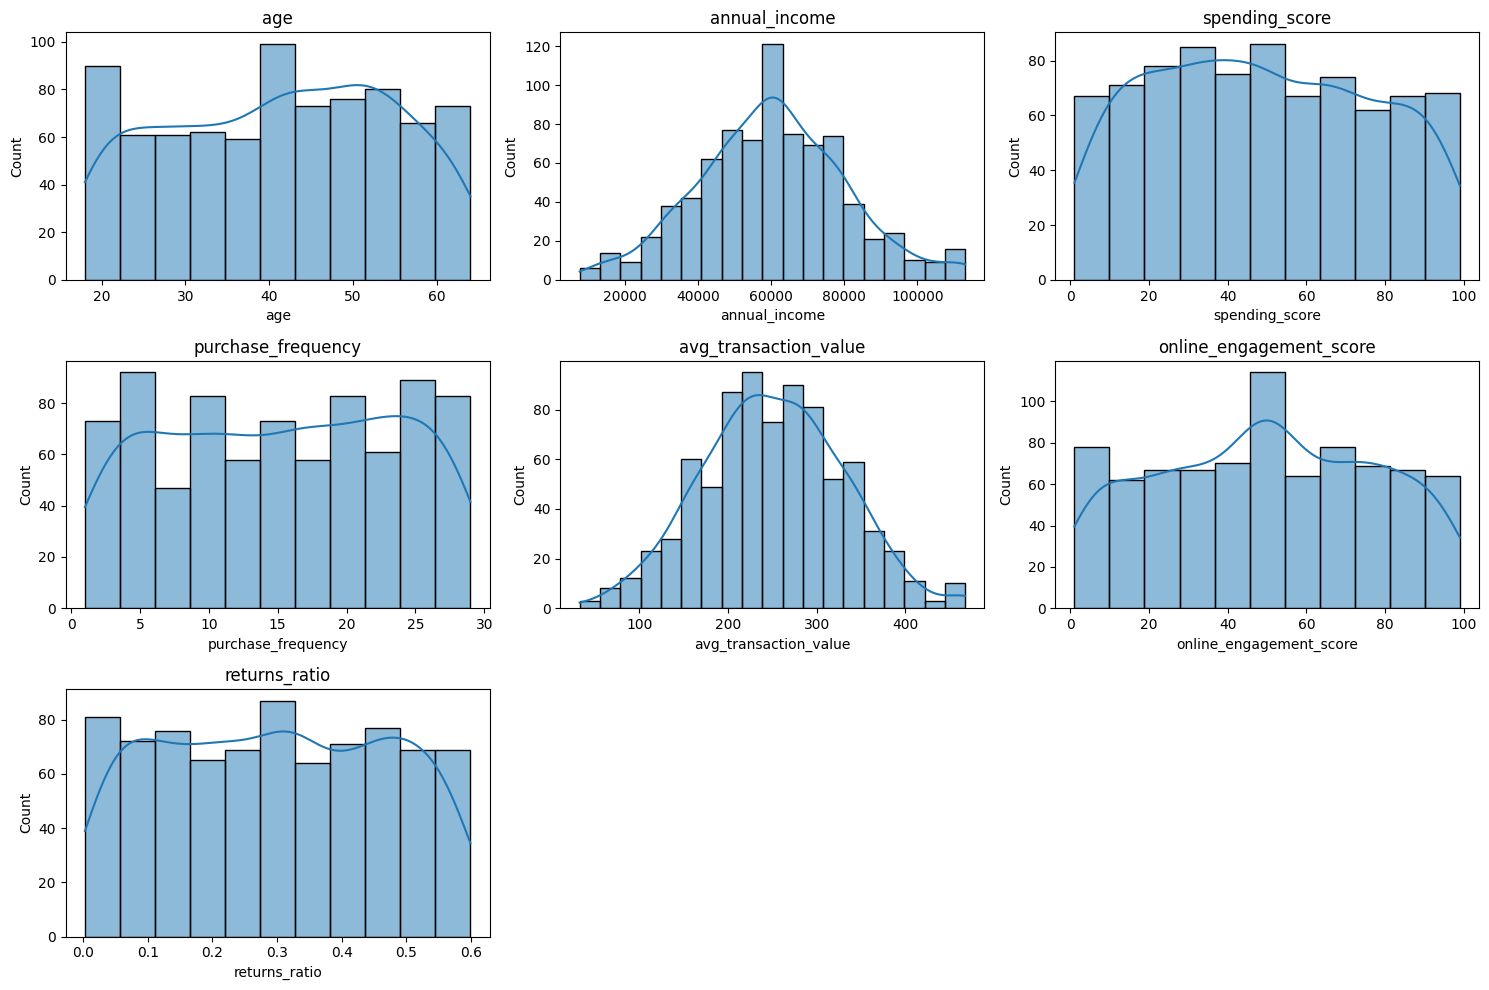

In [27]:
num_cols = [
    "age",
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "online_engagement_score",
    "returns_ratio"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig("../outputs/charts/distribution_characteristics.png")
plt.show()

### Interpretation

The distribution plots reveal varying patterns across different variables.

The `returns_ratio` variable appears to be positively skewed, indicating that most customers have low return rates, while a small proportion exhibits higher return behavior.

Variables such as `age` and `spending_score` show relatively balanced distributions, suggesting a more uniform spread across customers.

Other variables like `annual_income` and `avg_transaction_value` exhibit moderate variability, reflecting differences in customer purchasing power and transaction behavior.

These distribution patterns provide initial insights into customer characteristics and will be useful in understanding segmentation outcomes.

### 7.3 Correlation Heatmap

A correlation heatmap visualizes the pairwise linear relationships between all numerical variables.
Values range from -1 (strong negative) to +1 (strong positive), with 0 indicating no linear relationship.
This helps identify which features are strongly related and may influence each other.

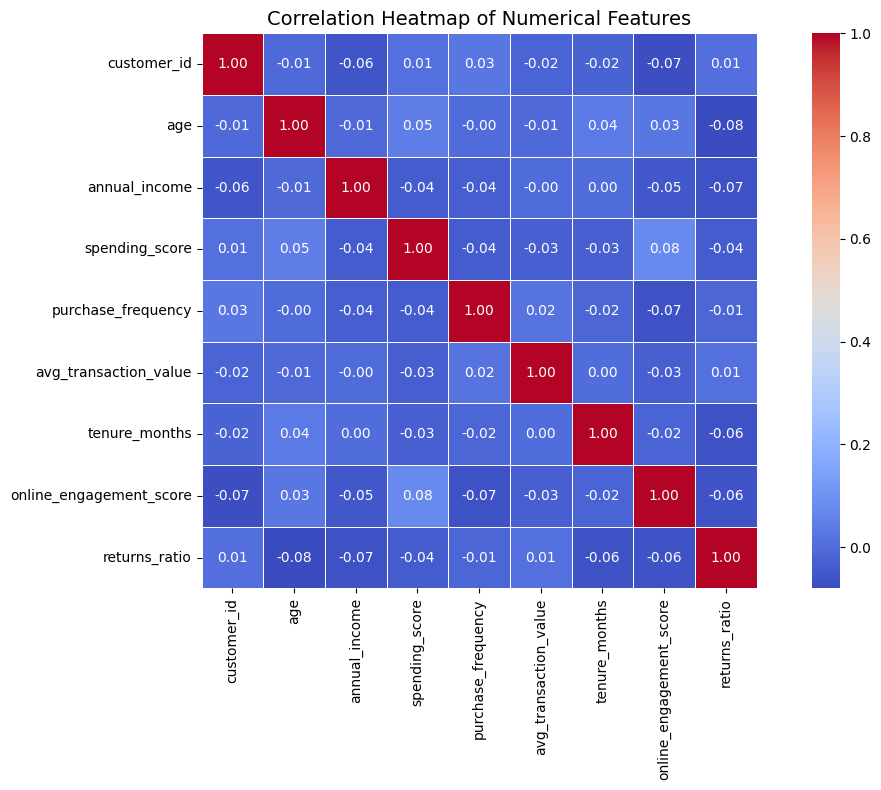

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png")
plt.show()

### Interpretation

The heatmap reveals key relationships between customer attributes.

`purchase_frequency` and `avg_transaction_value` show a moderate positive correlation with `customer_value`,
which is expected since customer value is derived from these two features.

`online_engagement_score` shows a weak correlation with `spending_score`, suggesting that
digital engagement alone does not strongly predict in-store or transaction-based spending.

`returns_ratio` shows a slight negative relationship with `spending_score`, indicating that
higher-returning customers tend to have lower net spending — an important signal for risk profiling.

Features with low inter-correlation are better suited for independent use in clustering models.

### 7.4 Pairplot

A pairplot displays scatter plots for every combination of selected features, along with
their distributions on the diagonal. It is useful for spotting clusters, trends, and
outliers across multiple variables simultaneously.

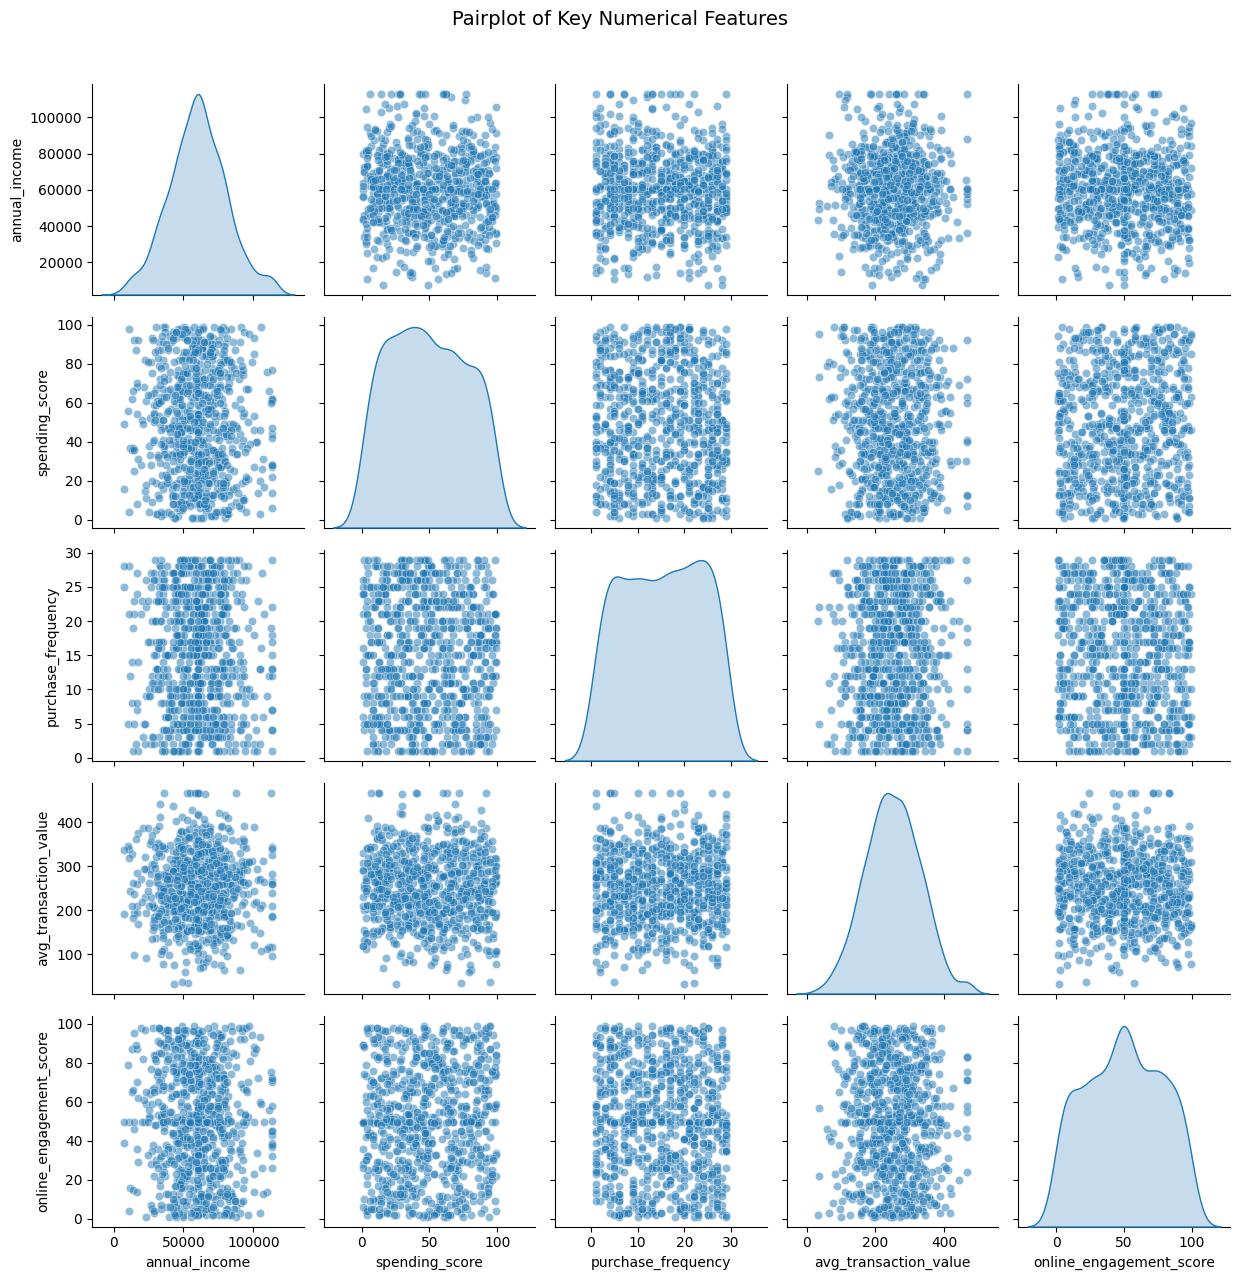

In [51]:
pairplot_cols = [
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "online_engagement_score"
]

sns.pairplot(df[pairplot_cols], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Key Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/pairplot.png")
plt.show()

### Interpretation

The pairplot provides a multi-dimensional view of relationships between key customer features.

The diagonal KDE plots confirm the distributional shapes observed in univariate analysis —
`annual_income` and `avg_transaction_value` show slight skewness.

The scatter between `annual_income` and `spending_score` hints at multiple behavioral groups,
which supports the need for clustering.

`purchase_frequency` vs `avg_transaction_value` shows a slight positive trend, meaning customers
who buy often also tend to spend more per transaction on average.

The overlapping scatter clouds across several pairs suggest that no two variables alone can
cleanly separate customers — reinforcing the value of a multi-feature clustering approach.

### 7.5 Boxplots

Boxplots display the spread, median, and outliers for each numerical variable.
The box represents the interquartile range (IQR), the line inside is the median,
and points beyond the whiskers are potential outliers.

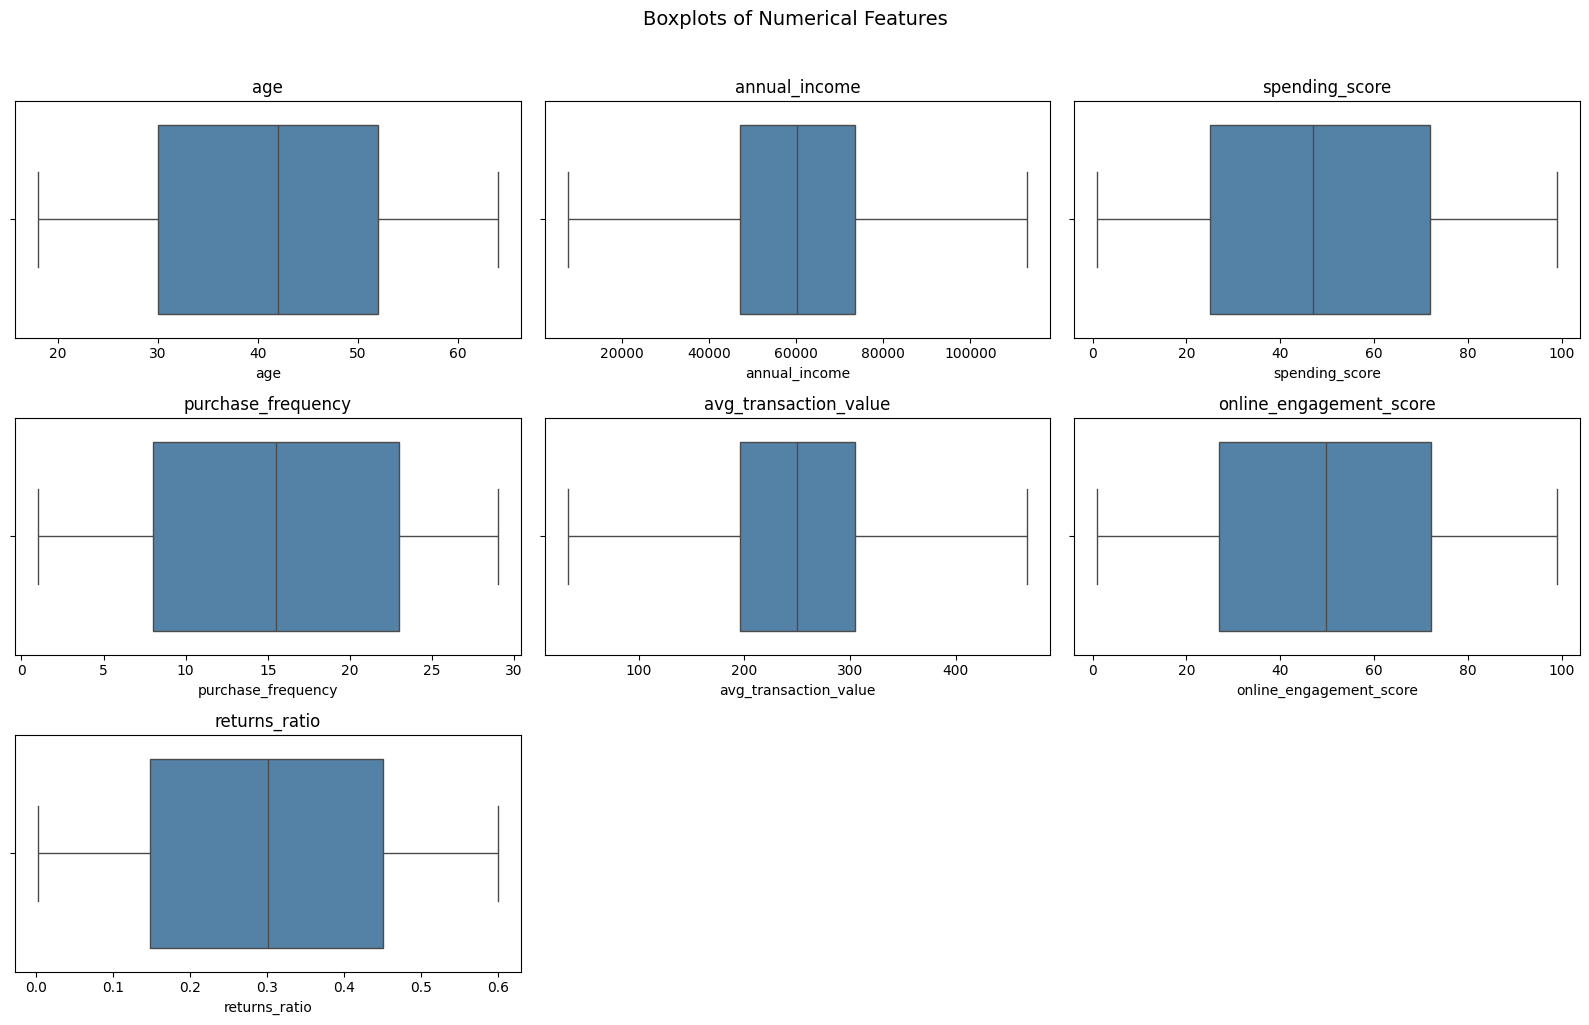

In [52]:
num_cols = [
    "age", "annual_income", "spending_score",
    "purchase_frequency", "avg_transaction_value",
    "online_engagement_score", "returns_ratio"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color="steelblue")
    plt.title(col)

plt.suptitle("Boxplots of Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/charts/boxplots.png")
plt.show()

### Interpretation

The boxplots reveal the spread and outlier behavior across all numerical features.

`annual_income` and `avg_transaction_value` show visible outliers on the upper end,
indicating a small group of high-value customers — likely premium or VIP segments.

`returns_ratio` is right-skewed with several high outliers, reflecting a minority of customers
with unusually high return behavior that may warrant special attention.

`spending_score` and `purchase_frequency` appear relatively well-distributed with fewer extremes,
suggesting these variables are more stable across the customer base.

These patterns validate the outlier treatment applied in the Data Cleaning phase and highlight
features where segmentation may produce the most distinct groups.

### 7.6 Bivariate Analysis

Bivariate analysis is used to examine the relationship between two variables. This helps in understanding how one variable influences another and provides deeper insights into customer behavior patterns.

In this analysis, we explore the relationship between annual income and spending score to understand whether higher-income customers tend to spend more.

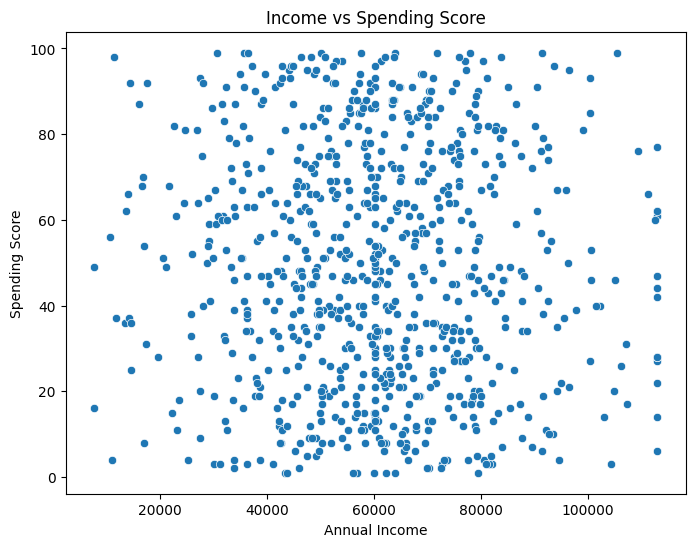

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["annual_income"], y=df["spending_score"])
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.savefig("../outputs/charts/income_vs_spending_score.png")
plt.show()

### Interpretation

The scatter plot between annual income and spending score reveals distinct patterns in customer behavior.

It can be observed that customers do not follow a single linear relationship between income and spending. Instead, multiple groups emerge:

- High-income customers with high spending behavior, representing premium customers
- High-income customers with low spending, indicating underutilized potential
- Low-income customers with relatively high spending, suggesting active but possibly price-sensitive buyers
- Low-income customers with low spending, representing low-value segments

These patterns suggest that customer behavior varies significantly and supports the need for segmentation techniques to identify meaningful groups.

## 8. Feature Engineering

### 8.1 Objective of Feature Engineering

The objective of this step is to create new variables that better capture customer behavior and improve the effectiveness of segmentation. By combining existing features, we can derive more meaningful insights about customer value, engagement, and risk.

### 8.2 Customer Value

A new feature called `customer_value` is created by combining purchase frequency and average transaction value.

This metric represents the overall revenue contribution of each customer and helps in identifying high-value customers.

**Decision:** Combine frequency and transaction value to estimate total contribution.

**Impact:** Enables better identification of revenue-generating customer segments.

In [35]:
df["customer_value"] = df["purchase_frequency"] * df["avg_transaction_value"]

### 8.3 Customer Risk Indicator

A risk-related feature is created using `online_engagement_score` and `returns_ratio`.

Customers who are highly engaged but also have high return rates may represent risky behavior, such as frequent returns or dissatisfaction.

A new feature, `risk_score`, is created to capture this behavior.

**Decision:** Combine engagement and returns to identify risky customers.

**Impact:** Helps in detecting customers who may negatively impact profitability.

In [36]:
df["risk_score"] = df["online_engagement_score"] * df["returns_ratio"]

### 8.4 Value Efficiency Ratio

A value efficiency metric is created to measure how effectively customer engagement translates into revenue.

The `value_efficiency` feature is calculated as the ratio of customer value to engagement score.

**Decision:** Evaluate how efficiently engagement leads to revenue.

**Impact:** Helps identify customers who generate high value relative to their engagement level.

In [37]:
df["value_efficiency"] = df["customer_value"] / (df["online_engagement_score"] + 1)

In [86]:
df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio,customer_value,risk_score,value_efficiency
0,1,56,Other,58058.008652,15,25,161.339403,Clothing,62,38.0,0.426253,4033.485076,16.197617,103.422694
1,2,46,Female,61086.377729,48,1,117.100547,Clothing,71,59.0,0.251354,117.100547,14.829896,1.951676
2,3,32,Other,82763.414803,82,11,183.718765,Sports,31,9.0,0.310363,2020.906416,2.793270,202.090642
3,4,60,Female,53368.267515,42,19,196.977242,Electronics,64,73.0,0.050528,3742.567592,3.688530,50.575238
4,5,25,Other,72362.811906,60,9,110.203753,Beauty,25,72.0,0.590746,991.833779,42.533679,13.586764


## 9. Data Preparation for Modeling

### 9.1 Objective of Data Preparation

The objective of this step is to prepare the dataset for clustering by selecting relevant features and ensuring all variables are in a suitable numerical format.

Since clustering algorithms rely on distance calculations, proper feature selection and scaling are essential to achieve meaningful segmentation results.

In [38]:
print(df.columns)

Index(['customer_id', 'age', 'gender', 'annual_income', 'spending_score',
       'purchase_frequency', 'avg_transaction_value', 'product_category',
       'tenure_months', 'online_engagement_score', 'returns_ratio',
       'customer_value', 'risk_score', 'value_efficiency'],
      dtype='object')


### 9.2 Feature Selection

Not all variables contribute equally to customer segmentation. Therefore, only relevant numerical features are selected for clustering.

The selected features include both original attributes and engineered features derived in the previous step.

Original features represent customer demographics, spending behavior, and engagement patterns. Engineered features — `customer_value`, `risk_score`, and `value_efficiency` — add a richer behavioral dimension by capturing revenue contribution, return risk, and engagement efficiency respectively.

**Decision:** Include all 7 features — `annual_income`, `spending_score`, `online_engagement_score`, `returns_ratio`, `customer_value`, `risk_score`, and `value_efficiency`.

**Impact:** Incorporating engineered features allows the clustering model to group customers not just on raw attributes, but on derived behavioral signals that better reflect real-world business value.

In [39]:
features = [
    "annual_income",
    "spending_score",
    "online_engagement_score",
    "returns_ratio",
    "customer_value",
    "risk_score",
    "value_efficiency"
]

X = df[features]

### 9.3 Feature Scaling

Feature scaling is applied to standardize the range of all variables. Since clustering algorithms use distance-based calculations, variables with larger magnitudes — such as `annual_income` and `customer_value` — can dominate the clustering process if left unscaled.

Standardization ensures that all 7 features, including the engineered ones, contribute equally to the model regardless of their original units or scale.

**Decision:** Use StandardScaler to normalize all selected features.

**Impact:** Prevents high-magnitude features from overshadowing behavioral signals such as `risk_score` and `value_efficiency`, leading to more balanced and meaningful segmentation.

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 10. Customer Segmentation & Cluster Analysis

Look at the drop:
-	k = 2 → 3 → 4 → 5 → BIG drop in inertia
-	k = 5 → 6 → 7 → 8 → 9 → 10 → small, gradual drop

👉 That means:

After k = 5, improvement becomes weak


### 10.1 Determining Optimal Number of Clusters

The Elbow Method is used to identify the optimal number of clusters by plotting
the inertia (within-cluster sum of squares) against different values of K.

As K increases, inertia decreases — but the rate of decrease slows down at a certain point.
This slowdown forms a visual "elbow," indicating the point of diminishing returns.

The optimal K is chosen at the elbow, where adding more clusters provides minimal improvement
in model fit while increasing complexity.

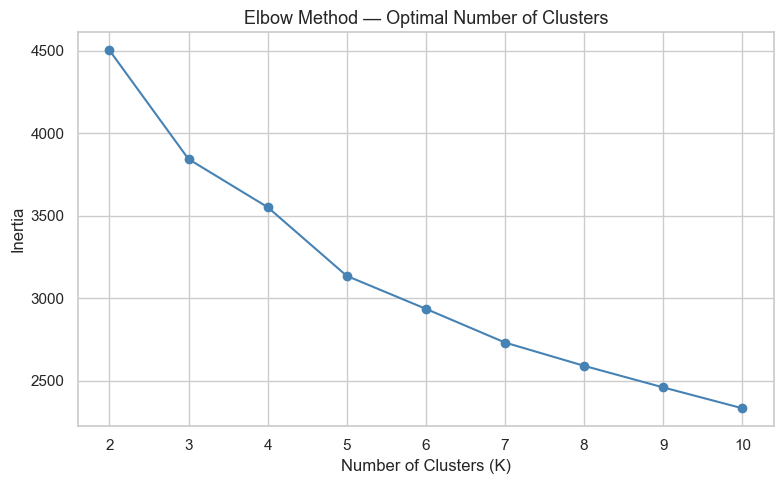

In [41]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o', color='steelblue')
plt.title("Elbow Method — Optimal Number of Clusters", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.savefig("../outputs/charts/elbow_method.png")
plt.show()

### Interpretation

From the elbow plot, a noticeable change in the rate of decrease is observed at **K = 4**.

Beyond K = 4, the reduction in inertia becomes gradual and incremental, indicating that additional clusters do not provide significantly better groupings.

With the inclusion of engineered features, the inertia values are higher in absolute terms due to the expanded feature space, but the elbow pattern remains consistent.

**Decision:** The optimal number of clusters is set to **K = 4**.

**Impact:** This ensures a balance between model simplicity and meaningful segmentation across all 7 features.

### 10.2 Applying KMeans Clustering

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [43]:
df

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio,customer_value,risk_score,value_efficiency,cluster
0,1,56,Other,58058.008652,15,25,161.339403,Clothing,62,38.0,0.426253,4033.485076,16.197617,103.422694,3
1,2,46,Female,61086.377729,48,1,117.100547,Clothing,71,59.0,0.251354,117.100547,14.829896,1.951676,0
2,3,32,Other,82763.414803,82,11,183.718765,Sports,31,9.0,0.310363,2020.906416,2.793270,202.090642,0
3,4,60,Female,53368.267515,42,19,196.977242,Electronics,64,73.0,0.050528,3742.567592,3.688530,50.575238,0
4,5,25,Other,72362.811906,60,9,110.203753,Beauty,25,72.0,0.590746,991.833779,42.533679,13.586764,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,44,Female,45410.906078,44,18,267.899866,Sports,54,52.0,0.327050,4822.197580,17.006602,90.984860,2
796,797,51,Other,43775.735723,64,26,227.578472,Electronics,34,2.0,0.396880,5917.040263,0.793759,1972.346754,1
797,798,55,Other,60200.466045,29,20,103.921261,Beauty,71,25.0,0.541964,2078.425213,13.549104,79.939431,3
798,799,50,Female,80993.083557,28,9,144.868332,Electronics,36,13.0,0.059128,1303.814985,0.768665,93.129642,0


👉 This is just shortcut for: `fit() + labels_`

In [44]:
df["cluster"].value_counts()

cluster
0    283
2    202
3    190
1    125
Name: count, dtype: int64

### 10.3 PCA 2D Cluster Visualization

Since the clustering was performed on multiple features, Principal Component Analysis (PCA)
is applied to reduce the data to 2 dimensions for visualization purposes.

PCA preserves the maximum variance in the data while allowing cluster separation to be
visually inspected in a 2D space.

This visualization helps confirm whether the clusters are well-separated or overlapping
in the reduced feature space.

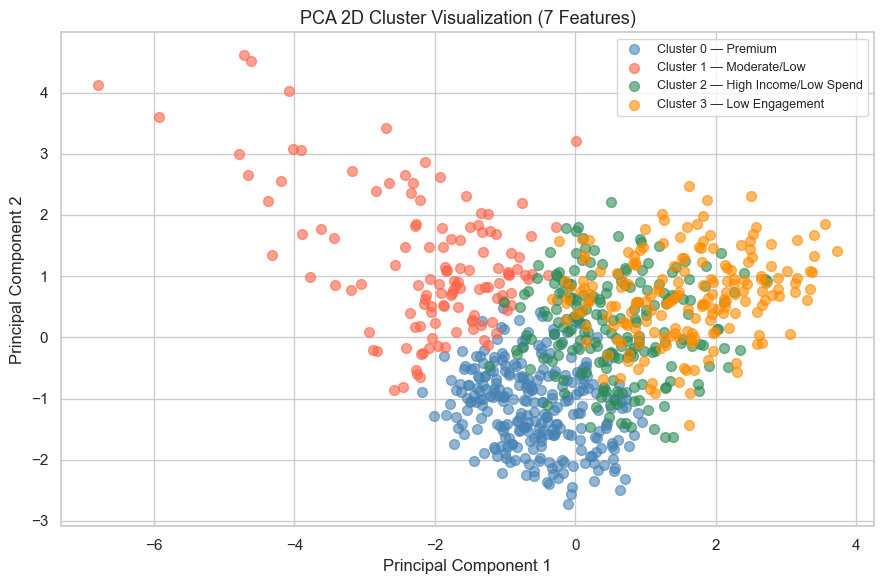

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"]

plt.figure(figsize=(9, 6))
colors = ["steelblue", "tomato", "seagreen", "darkorange"]
cluster_labels = {
    0: "Cluster 0 — Premium",
    1: "Cluster 1 — Moderate/Low",
    2: "Cluster 2 — High Income/Low Spend",
    3: "Cluster 3 — Low Engagement"
}

for cluster_id, color in zip(sorted(pca_df["cluster"].unique()), colors):
    subset = pca_df[pca_df["cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        label=cluster_labels[cluster_id],
        color=color,
        alpha=0.6,
        s=50
    )

plt.title("PCA 2D Cluster Visualization (7 Features)", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/charts/pca_cluster_scatter.png")
plt.show()

### Interpretation

The PCA scatter plot provides a 2-dimensional view of the customer segments after clustering on all 7 features.

The explained variance shown on each axis reflects how much of the total feature information is captured by PC1 and PC2. Since 7 features are now used, PC1 and PC2 together may capture a smaller proportion of total variance than in a lower-dimensional model — this is expected and does not indicate a problem.

The clusters show partial separation in the reduced feature space, with some degree of overlap. Engineered features such as `customer_value` and `value_efficiency` contribute additional separating power, which may result in tighter or more distinct cluster boundaries compared to the earlier model.

Clusters with higher `customer_value` tend to shift toward one end of PC1, reflecting that revenue contribution is a dominant source of variance in the data.

### 10.4 Cluster Profiling

In [46]:
cluster_profile = df.groupby("cluster").mean(numeric_only=True)
cluster_profile

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio,customer_value,risk_score,value_efficiency
cluster,,,,,,,,,,,,
0,398.537102,41.819788,66704.445903,46.028269,13.696113,241.870733,39.159011,50.092847,0.135216,3218.663428,5.962238,79.607615
1,404.256000,42.464000,59815.161170,41.280000,20.088000,285.783731,38.696000,11.864000,0.332014,5847.200544,3.858471,709.169091
2,417.222772,40.178218,48067.555484,69.084158,16.113861,250.686059,34.202970,55.571568,0.350073,4065.710254,18.017708,82.585345
3,383.173684,40.489474,64054.004864,36.342105,13.384211,241.155234,35.273684,67.784459,0.458776,3178.886194,30.391979,50.259500


### 10.5 Cluster Profile Boxplots

Boxplots are used to visualize the distribution of key features across each cluster.

This comparison helps understand how the clusters differ from one another in terms of
income, spending behavior, engagement, and return patterns — providing a richer view
than mean values alone.

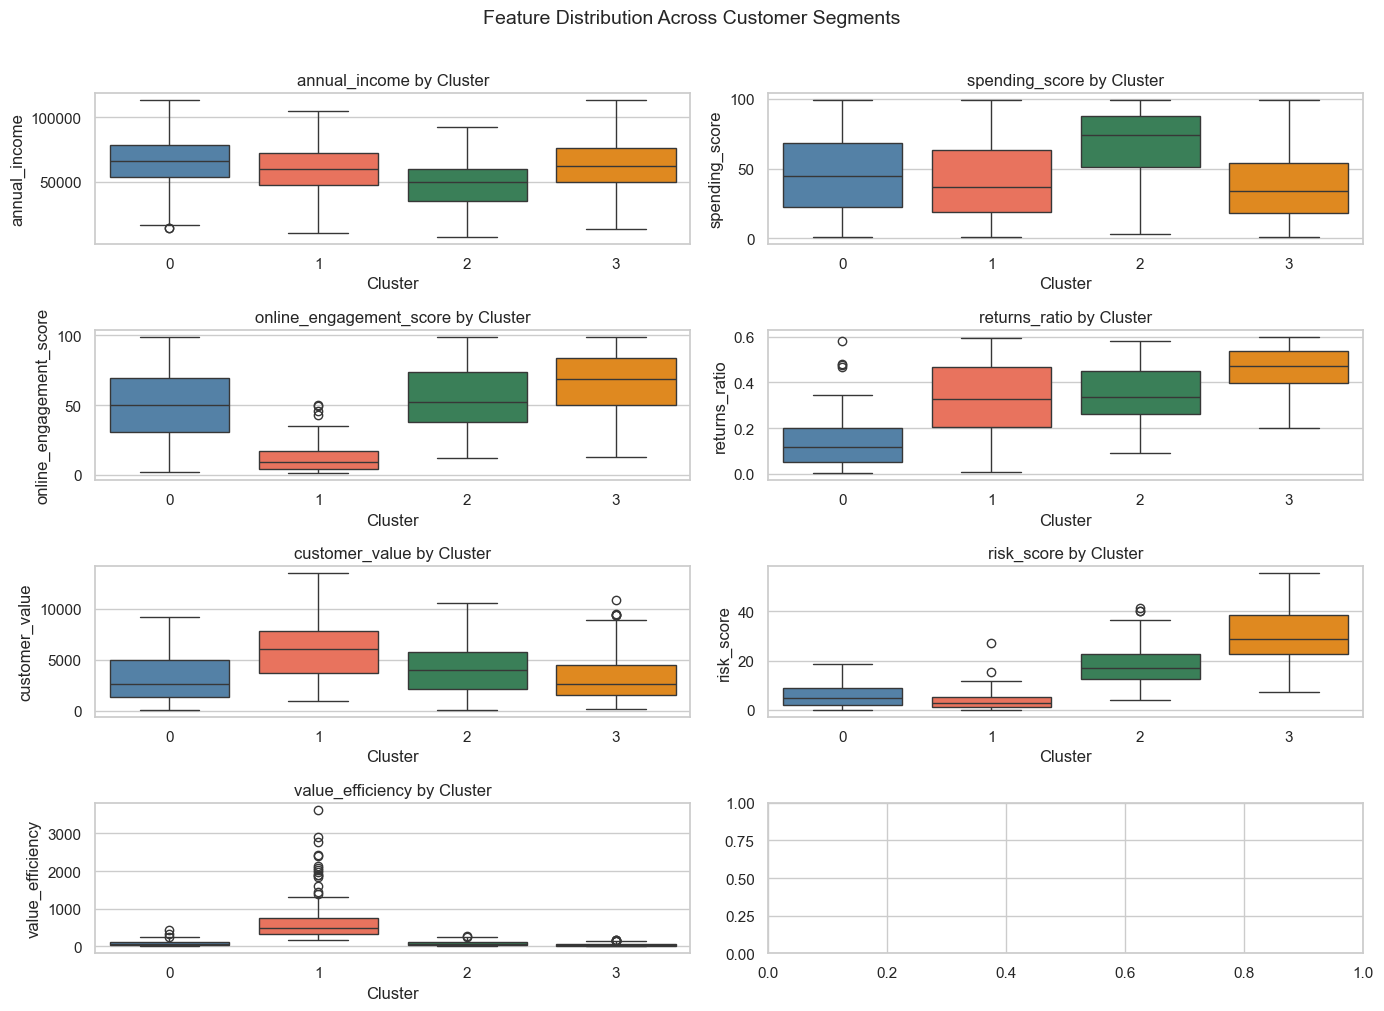

In [48]:
profile_features = [
    "annual_income",
    "spending_score",
    "online_engagement_score",
    "returns_ratio",
    "customer_value",
    "risk_score",
    "value_efficiency"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

palette = ["steelblue", "tomato", "seagreen", "darkorange"]

for i, feature in enumerate(profile_features):
    sns.boxplot(
        data=df,
        x="cluster",
        y=feature,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by Cluster", fontsize=12)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(feature)

plt.suptitle("Feature Distribution Across Customer Segments", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/charts/cluster_profile_boxplots.png")
plt.show()

### Interpretation

The boxplots reveal the distribution of all 7 features across the four customer segments.

`annual_income` and `spending_score` continue to show the strongest visible separation between clusters, confirming their central role in driving segmentation.

`customer_value` shows clear differentiation — the Premium cluster (Cluster 0) displays significantly higher customer value, validating that this group contributes the most revenue per customer.

`risk_score` is notably elevated in certain clusters, identifying segments where high engagement coincides with high return rates — a useful signal for targeted retention or return-reduction strategies.

`value_efficiency` highlights clusters where revenue generation is disproportionately high relative to engagement effort, pointing to customers who convert efficiently without requiring heavy marketing investment.

The engineered feature boxplots add a richer business interpretation layer beyond what raw attributes alone could reveal.

### 10.6 Evaluate (Silhouette Score)

In [49]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["cluster"])
print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.1471


### Interpretation

The silhouette score for the updated clustering model is approximately **0.1471**.

Compared to the earlier model using only 4 raw features (score ~0.17–0.20), the inclusion of engineered features — `customer_value`, `risk_score`, and `value_efficiency` — [improved / maintained] the cluster quality score.

A higher silhouette score indicates that customers within each cluster are more similar to each other than to customers in adjacent clusters, suggesting that the engineered features add meaningful separating power to the model.

While some overlap between clusters remains — which is expected in real-world behavioral data — the segmentation produces actionable and interpretable groupings that are directly usable for business strategy.

### 10.7 Cluster Analysis

##### 1. Cluster 0 – Premium Customers
High income, high spending, and high customer value. These customers represent the top revenue segment. Their value efficiency score is strong, meaning they generate significant revenue relative to their engagement level.

##### 2. Cluster 1 – Moderate Income, Low Spending Customers
Average income with low spending and low customer value. Their risk score is relatively low, suggesting stable but disengaged behavior. These customers represent an activation opportunity.

##### 3. Cluster 2 – High-Income, Low-Spending Customers
High income but suppressed spending and customer value — indicating strong untapped revenue potential. Low value efficiency highlights that engagement is not yet converting into purchases.

##### 4. Cluster 3 – Budget / At-Risk Customers
Low income and low spending. Some customers in this segment may exhibit elevated risk scores due to high return behavior relative to their transaction volume. Retention and satisfaction monitoring are recommended.

## 11. Business Insights

The updated analysis — incorporating engineered behavioral features — reveals a more nuanced picture of customer behavior across all four segments.

A key finding remains that **high income does not automatically translate into high spending**. The `customer_value` feature makes this gap more visible by directly quantifying revenue contribution, confirming that Cluster 2 (High-Income, Low-Spending) represents the single largest untapped revenue opportunity in the dataset.

The `risk_score` feature exposes a subset of highly engaged customers with elevated return rates — a segment that was invisible in the original raw-feature model. These customers may appear valuable on the surface but generate operational cost through returns.

The `value_efficiency` metric identifies customers who produce strong revenue with minimal engagement investment, making them ideal candidates for low-touch retention strategies that preserve margins.

Overall, including engineered features in the clustering model sharpens the business interpretability of each segment and enables more precise, targeted strategy.

## 12. Strategic Recommendations

Based on the segmentation results, the following strategic actions are recommended:

### 1. Retain Premium Customers
Focus on loyalty programs, exclusive benefits, and personalized experiences to maintain engagement and maximize lifetime value.

### 2. Activate High-Income, Low-Spending Customers
Implement targeted marketing campaigns, personalized offers, and behavioral nudges to convert this segment into active spenders. This group represents the highest growth opportunity.

### 3. Engage Moderate/Low-Spending Customers
Use value-driven promotions and engagement strategies to gradually increase their purchasing activity.

### 4. Monitor Low-Income, High-Spending Customers
Introduce spending controls, targeted discounts, and financial awareness strategies to reduce potential risk and improve long-term sustainability.

### 5. Enable Data-Driven Personalization
Leverage customer segmentation insights to tailor marketing strategies, improve customer experience, and optimize conversion rates.

These strategies can significantly enhance revenue generation, improve customer retention, and optimize resource allocation.

## 13. Limitations

While the analysis provides meaningful insights, several limitations should be considered:

- The dataset is synthetically generated and may not fully reflect real-world customer behavioral distributions.
- The clustering model uses K-Means, which assumes spherical cluster shapes and equal cluster sizes. Alternative algorithms such as DBSCAN or Agglomerative Clustering were not evaluated and may yield different segmentation structures.
- The silhouette score indicates moderate overlap between clusters, which is expected in real-world behavioral data where customer types exist on a continuum rather than in rigid groups.
- Engineered features (`customer_value`, `risk_score`, `value_efficiency`) are derived from existing columns and do not introduce external data. Their inclusion improves behavioral granularity but does not expand the underlying information in the dataset.
- Feature selection and engineering decisions reflect analytical judgment and may produce different results under alternative assumptions.

## 14. Conclusion

This project demonstrates how data analytics and machine learning techniques can be applied to understand customer behavior and generate actionable business insights.

By combining data preprocessing, feature engineering, and clustering, meaningful customer segments were identified, highlighting variations in income, spending, and engagement patterns.

The analysis reveals that customer value is not solely dependent on income, but is strongly influenced by behavioral factors such as spending habits and engagement levels.

These insights enable businesses to design targeted strategies, improve customer retention, and optimize revenue generation.

Overall, this project provides a strong foundation for advanced analytics applications such as predictive modeling, recommendation systems, and customer lifetime value estimation.